# CNASim Performance

The experiment evaluates tree reconstruction performance on CNAsim data. This notebook shows the workflow steps.

In [85]:
# autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
import os

import scgenome.plotting as pl
import anndata
import pandas as pd
from Bio import Phylo
from io import StringIO

from cellmates.utils.tree_utils import write_newick, nxtree_to_newick, newick_to_nx


In [69]:
# data is generated from CNAsim

In [70]:
# converted to anndata

In [92]:
data_path = "../../../output/reproducibility/workflows/cnasim_performance/data/R2_N10_M100_K2_L5_E10.04_E20.1_C1"

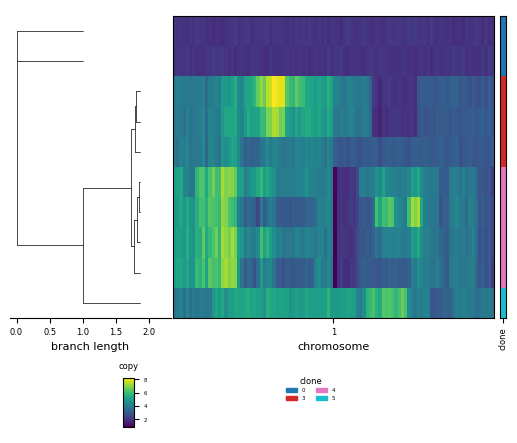

In [93]:
# plot example
adata = anndata.read_h5ad(os.path.join(data_path, "input.h5ad"))
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=['clone'], raw=True)

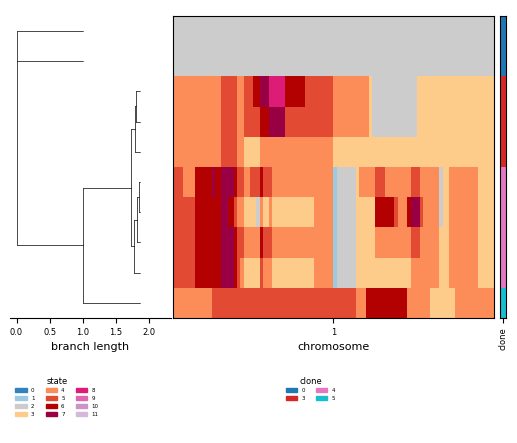

In [94]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree, annotation_fields=['clone'])

In [95]:
gt_tree_nwk = adata.uns['cell-tree-newick']
print(gt_tree_nwk)

(cell1:1.0,cell2:1.0,((((cell6:0.0638145886861041,cell7:0.0638145886861041)ancestor4:0.01187777210220826,cell4:0.07569236078831236)ancestor2:0.05573481379672617,(((cell10:0.01488940835361242,cell9:0.01488940835361242)ancestor6:0.03366523170172608,cell8:0.04855464005533851)ancestor5:0.04458833185488487,cell5:0.09314297191022337)ancestor3:0.03828420267481515)ancestor1:0.7263054144136212,cell3:0.8577325889986597)founder:1.0)root;


In [96]:
print(bio_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=1.0, name='cell1')
        Clade(branch_length=1.0, name='cell2')
        Clade(branch_length=1.0, name='founder')
            Clade(branch_length=0.7263054144136212, name='ancestor1')
                Clade(branch_length=0.05573481379672617, name='ancestor2')
                    Clade(branch_length=0.01187777210220826, name='ancestor4')
                        Clade(branch_length=0.0638145886861041, name='cell6')
                        Clade(branch_length=0.0638145886861041, name='cell7')
                    Clade(branch_length=0.07569236078831236, name='cell4')
                Clade(branch_length=0.03828420267481515, name='ancestor3')
                    Clade(branch_length=0.04458833185488487, name='ancestor5')
                        Clade(branch_length=0.03366523170172608, name='ancestor6')
                            Clade(branch_length=0.01488940835361242, name='cell10')
                           

In [97]:
em_nwk = open(os.path.join(data_path, "cm_out", "tree.nwk")).read()
print(em_nwk)

(((cell8:-0.0,cell9:-0.0)ancestor3:0.0,((cell2:-0.0,cell3:-0.0)ancestor7:0.0,(cell1:-0.0,cell10:-0.0)ancestor8:0.0)ancestor4:0.0)ancestor1:-0.0,((cell6:-0.0,cell7:-0.0)ancestor5:0.0,(cell4:-0.0,cell5:-0.0)ancestor6:0.0)ancestor2:-0.0)root;


In [99]:
inferred_tree = Phylo.read(os.path.join(data_path, "cm_out", "tree.nwk"), 'newick')

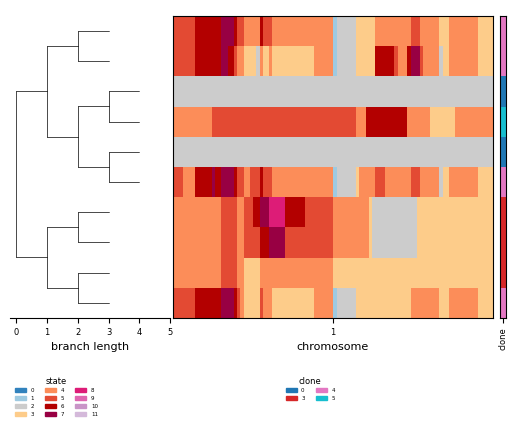

In [100]:
# output tree
# print(inferred_tree)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=inferred_tree, annotation_fields=['clone'])
